<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/EDA/2_3_Muestreo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>


<center><h1>Estadística para la Ciencia de Datos</header1></center>
<left><h1>Unidad 2: Inferencia y estimación de datos</header1></left>

# Muestreo

In [ ]:
# paquetes necesarios en esta sección
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## usar youtube
from IPython.display import YouTubeVideo

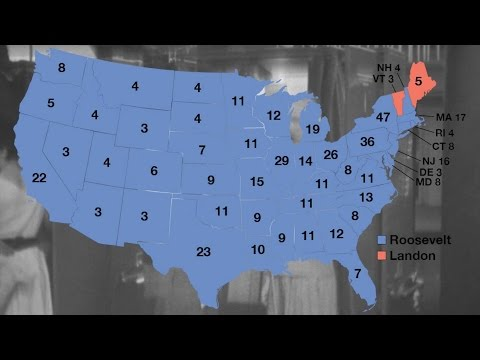

In [ ]:
# ID del video de YouTube
video_id = "JwZo28RKdvU"

# Mostramos el video con el comando YouTubeVideo
YouTubeVideo(video_id)

*En el ejemplo de la encuesta del Literary Digest de 1936 que predijo una victoria de Alf Landon sobre Franklin Roosevelt. El Literary Digest, uno de los principales diarios, encuestó a sus suscriptores además de hacerlo a los individuos que figuraban en otras listas, llegando a un total de más de 10 millones de personas, y predijo una victoria aplastante de Landon. George Gallup, fundador de Gallup Poll, realizó encuestas quincenales a solo 2000 personas y predijo acertadamente una victoria de Roosevelt. La diferencia radica en la selección de los encuestados.*

*Literary Digest apostó por la cantidad, prestando poca atención al método de selección. Terminaron encuestando a personas con un estatus socioeconómico relativamente alto (sus propios suscriptores, más aquellos que, en virtud de poseer lo que se consideraban lujos como eran los teléfonos y automóviles, aparecían en las listas de los especialistas en marketing). El resultado fue el sesgo de la muestra (sample bias), es decir, la muestra era, de manera significativa y no aleatoria, diferente de la población más grande a la que se pretendía representar. El término no aleatorio (nonrandom) es importante: casi ninguna muestra, incluidas las aleatorias, será exactamente representativa de la población. El sesgo ocurre cuando la diferencia es significativa y se puede esperar que continúe para otras muestras extraídas del mismo modo que la primera.*

De aquí es importante revisar los siguientes conceptos:

![Texto alternativo](https://drive.google.com/uc?id=1-l5pZIEj6EjOhjRyuOuhc7J5Ksx7-KZE)

## Ejemplo: Tipos de Café

In [ ]:
path='https://github.com/JSebasB90/datasets/raw/refs/heads/main/coffee_ratings_full.feather'

In [ ]:
df = pd.read_feather(path)
df.head()

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,None,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,None,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",None,None,None,None,1600 - 1800 m,...,None,0.0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,None,wolensu,None,yidnekachew debessa coffee plantation,1800-2200,...,Green,2.0,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,None,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [ ]:
df.columns

Index(['total_cup_points', 'species', 'owner', 'country_of_origin',
       'farm_name', 'lot_number', 'mill', 'ico_number', 'company', 'altitude',
       'region', 'producer', 'number_of_bags', 'bag_weight',
       'in_country_partner', 'harvest_year', 'grading_date', 'owner_1',
       'variety', 'processing_method', 'aroma', 'flavor', 'aftertaste',
       'acidity', 'body', 'balance', 'uniformity', 'clean_cup', 'sweetness',
       'cupper_points', 'moisture', 'category_one_defects', 'quakers', 'color',
       'category_two_defects', 'expiration', 'certification_body',
       'certification_address', 'certification_contact', 'unit_of_measurement',
       'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters'],
      dtype='object')

Intentemos tomar muestras de este dataframe para la variable *total_cup_points*

In [ ]:
# media poblacional
print(df['total_cup_points'].mean())

82.15120328849028


In [ ]:
# los primeros 10 valores
primeros10 = df.head(10)
print(primeros10['total_cup_points'].mean())

89.1


Vemos la diferencia de la selección con histogramas:

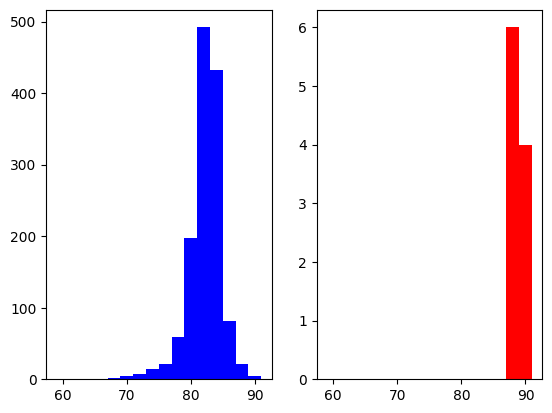

In [ ]:
fig, ax = plt.subplots(1, 2)
#primer gráfico
ax[0].hist(df["total_cup_points"], bins=np.arange(59, 93, 2), color='b')
#segundo gráfico
ax[1].hist(primeros10["total_cup_points"], bins=np.arange(59, 93, 2),  color='r')
plt.show()

Este tipo de muestreo se llama muestreo por conveniencia, y tiene un claro sesgo.

Veamos que sucede cuando agregamos una muestra aleatoria:

In [ ]:
coffee_sample = df.sample(n=10, random_state=1492)
print(coffee_sample['total_cup_points'].mean())

82.11699999999999


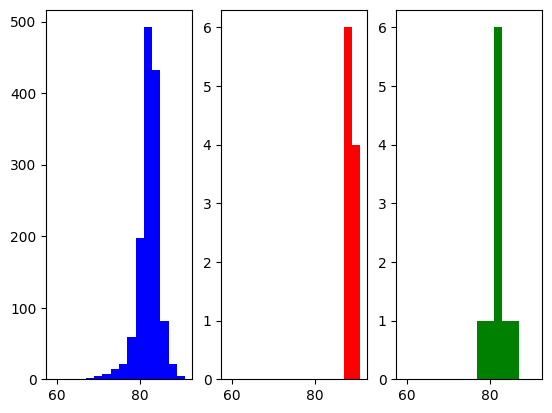

In [ ]:
fig, ax = plt.subplots(1, 3)
#primer gráfico
ax[0].hist(df["total_cup_points"], bins=np.arange(59, 93, 2), color='b')
#segundo gráfico
ax[1].hist(primeros10["total_cup_points"], bins=np.arange(59, 93, 2),  color='r')
#tercer gráfico
ax[2].hist(coffee_sample["total_cup_points"], bins=np.arange(59, 93, 2),  color='g')
plt.show()

Aquí, estamos bajo la incertidumbre del azar, no existe propiamente la generación de números aleatorios en computación.

Una estrategia muy usada es el **muestreo sistemático.**

- El *muestreo sistemático es un tipo de muestreo probabilístico en el que se seleccionan los elementos de una población siguiendo un intervalo fijo ($k$)*, después de elegir aleatoriamente el primer elemento dentro de los primeros $k$ elementos. Es una técnica sencilla y eficiente cuando los datos están ordenados o disponibles en una lista, ya que garantiza una cobertura uniforme de toda la población sin tener que usar números aleatorios para cada selección.

In [ ]:
sample_size = 10
pop_size = len(df)
print(pop_size)

1338


In [ ]:
interval = pop_size // sample_size
print(interval)

133


In [ ]:
coffe_sist = df.iloc[::interval]
print(coffe_sist['total_cup_points'].mean())

82.84818181818183


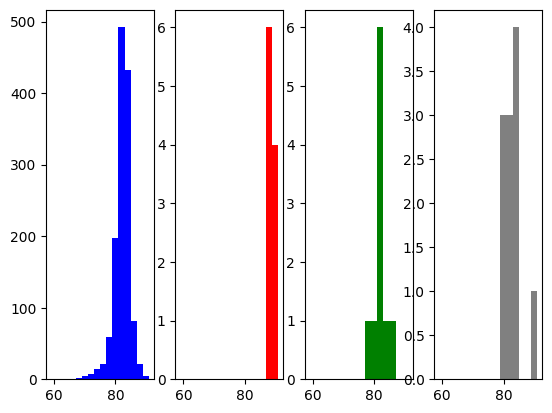

In [ ]:
fig, ax = plt.subplots(1, 4)
#primer gráfico
ax[0].hist(df["total_cup_points"], bins=np.arange(59, 93, 2), color='b')
#segundo gráfico
ax[1].hist(primeros10["total_cup_points"], bins=np.arange(59, 93, 2),  color='r')
#tercer gráfico
ax[2].hist(coffee_sample["total_cup_points"], bins=np.arange(59, 93, 2),  color='g')
#cuarto gráfico
ax[3].hist(coffe_sist["total_cup_points"], bins=np.arange(59, 93, 2),  color='gray')
plt.show()

En ocasiones, necesitamos garantizar que nuestra muestra represente todas las sub-poblaciones existentes, para esto usamos **Muestreo aleatorio estratificado.**

![Texto alternativo](https://drive.google.com/uc?id=1tDBjmF6tILvgMqez5Vzh3E2TDkSUIGwe)

Por ejemplo, vamos a seleccionar en nuestra muestra cafés de los 6 principales países de origen:

In [ ]:
top_counts = df['country_of_origin'].value_counts()
top_counts.head(6)

,count
country_of_origin,
Mexico,236
Colombia,183
Guatemala,181
Brazil,132
Taiwan,75
United States (Hawaii),73


In [ ]:
top_counted_countries = ["Mexico", "Colombia", "Guatemala", "Brazil", "Taiwan", "United States (Hawaii)"]

top_counted_subset = df['country_of_origin'].isin(top_counted_countries)

coffee_ratings_top = df[top_counted_subset]

In [ ]:
muestra_estr = coffee_ratings_top.sample(frac=0.1, random_state=2021) #10% de los datos
muestra_estr['country_of_origin'].value_counts(normalize=True)

,proportion
country_of_origin,
Mexico,0.250000
Guatemala,0.204545
Colombia,0.181818
Brazil,0.181818
United States (Hawaii),0.102273
Taiwan,0.079545


Comparemos con la población (filtrada en los 6 estratos):

In [ ]:
coffee_ratings_top['country_of_origin'].value_counts(normalize=True)

,proportion
country_of_origin,
Mexico,0.268182
Colombia,0.207955
Guatemala,0.205682
Brazil,0.150000
Taiwan,0.085227
United States (Hawaii),0.082955


Grafiquemos el dataset original, el filtro por estratos y la muestra:

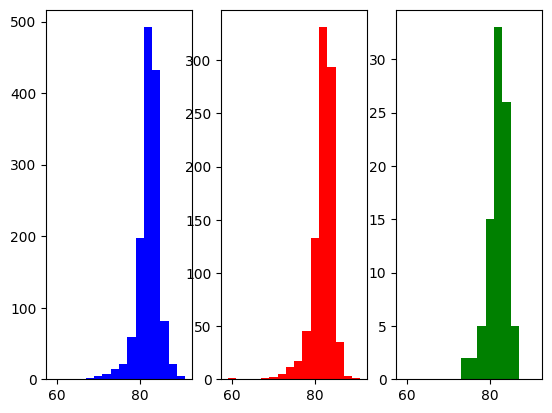

In [ ]:
fig, ax = plt.subplots(1, 3)
#primer gráfico
ax[0].hist(df["total_cup_points"], bins=np.arange(59, 93, 2), color='b')
#segundo gráfico
ax[1].hist(coffee_ratings_top["total_cup_points"], bins=np.arange(59, 93, 2),  color='r')
#tercer gráfico
ax[2].hist(muestra_estr["total_cup_points"], bins=np.arange(59, 93, 2),  color='g')
plt.show()

También se puede hacer un **muestreo ponderado** en el que buscamos imponer que un porcentaje fijo de una sub-población sea muestreado.

Por ejemplo, de origen Taiwan:

In [ ]:
condition = coffee_ratings_top['country_of_origin'] == "Taiwan"

In [ ]:
#crea la columna de pesos
coffee_ratings_top['weight'] = np.where(condition, 2, 1)

/tmp/ipykernel_12958/21843459.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coffee_ratings_top['weight'] = np.where(condition, 2, 1)


In [ ]:
#selecciona aleatoriamente el 10 % de las filas del DataFrame, pero ponderando las probabilidades según la columna "weight"
coffee_ratings_w = coffee_ratings_top.sample(frac=0.1, weights="weight")

Haciendo esto, todos los registros tienen chance de ser seleccionados, pero los de Taiwán tienen el doble de probabilidad que los demás.

In [ ]:
coffee_ratings_w['country_of_origin'].value_counts(normalize=True)

,proportion
country_of_origin,
Guatemala,0.261364
Mexico,0.204545
Brazil,0.181818
Colombia,0.159091
Taiwan,0.102273
United States (Hawaii),0.090909


## Error relativo de las estimaciones puntuales

Consideremos las siguientes medias muestrales:

In [ ]:
# media poblacional
media_pop = df['total_cup_points'].mean()
print(media_pop)

82.15120328849028


In [ ]:
# media de muestra de tamaño 10
muestra_10 = df.sample(n=10)['total_cup_points']
print(muestra_10.mean())

81.699


In [ ]:
# media de muestra de tamaño 100
muestra_100 = df.sample(n=100)['total_cup_points']
print(muestra_100.mean())

82.57519999999998


In [ ]:
# media de muestra de tamaño 1000
muestra_1000 = df.sample(n=1000)['total_cup_points']
print(muestra_1000.mean())

82.20203


Podemos calcular los errores:

In [ ]:
resultados = []

for sample_size in range(10, 1331, 1):
    sample_mean = df.sample(n=sample_size)['total_cup_points'].mean()
    error = media_pop - sample_mean
    rel_error_pct = 100 * abs(error) / media_pop

    resultados.append({
        "sample_size": sample_size,
        "relative_error": rel_error_pct
    })

In [ ]:
# Crear DataFrame con los resultados
errors = pd.DataFrame(resultados)

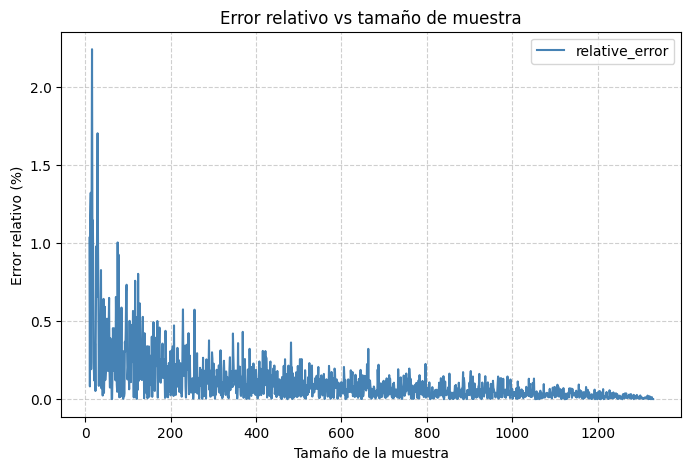

In [ ]:
# Grafico
errors.plot(x="sample_size", y="relative_error", kind="line", figsize=(8,5), color="steelblue")
plt.title("Error relativo vs tamaño de muestra")
plt.xlabel("Tamaño de la muestra")
plt.ylabel("Error relativo (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Propiedades:

- Ruido intenso, especialmente para muestras pequeñas.
- La amplitud es inicialmente pronunciada y luego se aplana.
- El error relativo disminuye a cero (cuando el tamaño de la muestra es igual a la población).

Como se ve, se estabiliza a partir de un momento adecuado, pero, ¿cual es el tamaño de la muestra adecuada?

**Estrategias mas usadas:**

- *La regla de los 30:* Se considera un punto de partida para muchos estudios, ya que a partir de 30 puntos de datos, las conclusiones estadísticas suelen ser sólidas.

- *Muestras de 200 a 300:* Para muchas encuestas y estudios, este tamaño de muestra proporciona un margen de error aceptable y se encuentra antes de la fase de "rendimientos decrecientes", donde añadir más participantes ofrece beneficios marginales.

- *"Más no siempre es mejor":* Si bien una muestra más grande generalmente aumenta la precisión, es crucial encontrar un equilibrio entre la precisión requerida, el presupuesto y el tiempo

Nos debemos cuidar del **sesgo de selección**, que se refiere a la práctica de elegir datos de forma selectiva, consciente o inconscientemente, de manera que lleve a una conclusión engañosa o pasajera.

![Texto alternativo](https://drive.google.com/uc?id=1QRVqWDWV72SOy0Y8QtoKQBL9lFbEPX47)

![Texto alternativo](https://drive.google.com/uc?id=1ponNkj3Bxev612Iyi7U66K3QoqFw0x7C)

Enlace recomendado [link](https://mlu-explain.github.io/bias-variance/)

## Distribuciones muestrales

Las **estimaciones o estadísticos** son aproximaciones de los valores desconocidos de una población a partir de una muestra de datos. En estadística, las estimaciones permiten hacer inferencias sobre toda una población sin necesidad de analizar cada uno de sus elementos, facilitando el análisis de grandes conjuntos de datos. Son fundamentales en estadística porque permiten a los científicos de datos, economistas y otros profesionales tomar decisiones informadas basadas en una porción representativa de datos.

Ejemplos de estimaciones incluyen:
- **media muestral** (estimación de la media poblacional)
- **proporción muestral** (para estimar la proporción en la población)
- **intervalo de confianza** (que ofrece un rango probable para un parámetro poblacional),
- **desviación estándar muestral** (como estimación de la dispersión en la población).

El término **distribución muestral** (sampling distribution) de un estadístico se refiere a la distribución del estadístico de una muestra sobre muchas muestras extraídas de la misma población. Gran parte de la estadística clásica se ocupa de hacer inferencias de muestras (pequeñas) a poblaciones (muy grandes).

Normalmente, *una muestra se extrae con el objetivo de medir algo* (con el estadístico muestral [sample statistic]) o modelar algo (con un modelo estadístico o de aprendizaje automático). Dado que nuestra estimación o modelo se basa en una muestra, podría dar lugar a error. Sería diferente si tuviéramos que extraer una muestra diferente. Por lo tanto, estamos interesados en cuánto de diferente podría ser: una preocupación clave es la variabilidad muestral (sampling variability). Si tuviéramos muchos datos, podríamos extraer muestras adicionales y observar la distribución del estadístico muestral directamente.

### Caso media muestral

En estadística, es común distinguir entre la media de una muestra y la media de una población para tener claridad sobre la fuente y alcance de los datos que analizamos. La **media de una muestra** se representa por el símbolo $\bar{x}$, mientras que la **media de una población** se representa con el símbolo $\mu$ (mu). Esta diferenciación es fundamental: mientras que $\mu$ denota el valor promedio de todos los datos en una población completa (algo que rara vez se puede obtener en su totalidad), $\bar{x}$ representa el promedio de un subconjunto de datos (o muestra) que se ha recolectado de la población.

Esta distinción ayuda a los estadísticos y científicos de datos a evitar confusiones y a aplicar métodos específicos según si los datos disponibles son de una muestra o de una población. Dado que la información de toda una población es difícil de obtener, **la media muestral** $\bar{x}$ se usa con frecuencia para **inferir** o **aproximar** la media poblacional $\mu$.

Es probable que la distribución de un estadístico muestral, como la media, sea más regular y adopte la forma de campana que la distribución de los datos en sí. Cuanto mayor sea la muestra en la que se fundamenta el estadístico, más cierta es esta afirmación. Además, cuanto mayor sea la muestra, más estrecha será la distribución del estadístico muestral.

Esto se ilustra en un ejemplo en el que se utilizan los ingresos anuales de los solicitantes de préstamos para LendingClub. *Donde se toman tres muestras de estos datos: una muestra de 1000 valores, una muestra de 1000 medias de 5 valores y una muestra de 1000 medias de 20 valores.*

Generemos la media de 5 muestras aleatorias, repetimos este proceso 1000 veces y generamos la distribución:

In [ ]:
mean_cup_points_1000 = []

for i in range(1000):
  mean_cup_points_1000.append(df.sample(n=5)['total_cup_points'].mean()
  )

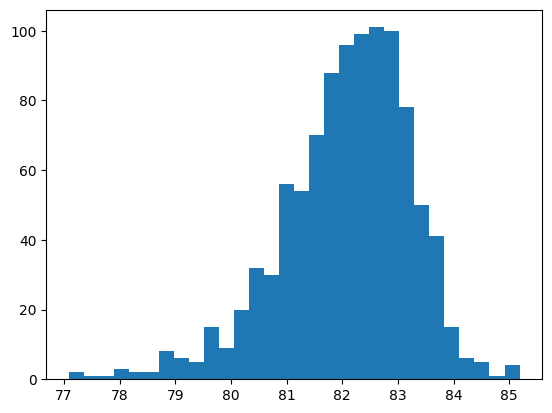

In [ ]:
plt.hist(mean_cup_points_1000, bins=30)
plt.show()

*Una distribución de muestreo es una distribución de réplicas de estimaciones puntuales.*

Vemos como varia con otro tamaño de muestra

In [ ]:
mean_cup_points_1000_2 = []

for i in range(1000):
  mean_cup_points_1000_2.append(df.sample(n=150)['total_cup_points'].mean()
  )

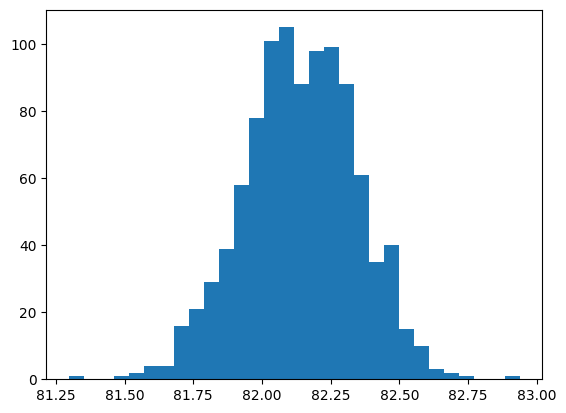

In [ ]:
plt.hist(mean_cup_points_1000_2, bins=30)
plt.show()

Aquí nuevamente vemos el impacto del TLC.